# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [32]:
import os
import pandas as pd
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Adjust the sys.path to include the project root directory
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.pybalmorel import MainResults
from src.pybalmorel.plotting import plot_functions as pf

#gams_system_directory = "/Library/Frameworks/GAMS.framework/Versions/54/Resources/"
gams_system_directory = '/Library/Frameworks/GAMS.framework/Resources'

In [33]:
# ### 1.1.2 Loading several scenarios
# res = MainResults(files=['MainResults_NZwoCCS.gdx',
#                          'MainResults_NZwoCCS_v2.gdx',
#                         'MainResults_NZwCCS2.gdx',
#                         'MainResults_NZwCCS_v3.gdx',
#                         'MainResults_CO2TaxwCCS_S26.gdx',
#                         'MainResults_NNwCCS.gdx',
#                         'MainResults_NNwCCS_v3.gdx',
#                         'MainResults_NZwCCSBio_s26.gdx'],
#                     paths=['Balmorel/02Project_NZwithoutCCS/Model',
#                            'Balmorel/02Project_NZwithoutCCS_S26/Model',
#                             'Balmorel/03Project_NZwCCS/Model',
#                             'Balmorel/03Project_NZwCCS_S26/Model',
#                             'Balmorel/04Project_CO2TaxwCCS_S26/Model',
#                             'Balmorel/05Project_NNwCCS/Model',
#                             'Balmorel/05Project_NNwCCS_S26/Model',
#                             'Balmorel/06Project_NZwCCSBio_S26/Model'],
#                     scenario_names=['Net-Zero w/o CCS', 
#                                     'Net-Zero w/o CCS s26', 
#                                     'Net-Zero w CCS', 
#                                     'Net-Zero w CCS s26', 
#                                     'CO2 Tax w CCS s26', 
#                                     'Net-Negative w CCS', 
#                                     'Net-Negative w CCS s26',
#                                     'Net-Zero w CCS and bio emissions s26'],
#                     system_directory=gams_system_directory)


In [34]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_NZwoCCS_v2.gdx',
                        'MainResults_NZwCCS_v3.gdx',
                        'MainResults_CO2TaxwCCS_S26.gdx',
                        'MainResults_NNwCCS_v3.gdx',
                        'MainResults_NZwCCSBio_s26.gdx'],
                    paths=['Balmorel/02Project_NZwithoutCCS_S26/Model',
                            'Balmorel/03Project_NZwCCS_S26/Model',
                            'Balmorel/04Project_CO2TaxwCCS_S26/Model',
                            'Balmorel/05Project_NNwCCS_S26/Model',
                            'Balmorel/06Project_NZwCCSBio_S26/Model'],
                    scenario_names=['Net-Zero w/o CCS s26',
                                    'Net-Zero w CCS s26', 
                                    'CO2 Tax w CCS s26', 
                                    'Net-Negative w CCS s26',
                                    'Net-Zero w CCS and bio emissions s26'],
                    system_directory=gams_system_directory)

Loading Balmorel/02Project_NZwithoutCCS_S26/Model/MainResults_NZwoCCS_v2.gdx
Loading Balmorel/03Project_NZwCCS_S26/Model/MainResults_NZwCCS_v3.gdx
Loading Balmorel/04Project_CO2TaxwCCS_S26/Model/MainResults_CO2TaxwCCS_S26.gdx
Loading Balmorel/05Project_NNwCCS_S26/Model/MainResults_NNwCCS_v3.gdx
Loading Balmorel/06Project_NZwCCSBio_S26/Model/MainResults_NZwCCSBio_s26.gdx


/Users/flora/Desktop/DTU master courses/2nd semester/large scale energy/ccs_balmorel_project/src/pybalmorel/classes.py:100: UserWarning: The GAMS version (53.5.1) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace(system_directory=system_directory)


In [35]:
F_CONS_YCRAT = pd.DataFrame(res.get_result('F_CONS_YCRAST'))
PRO_YCRAGF = pd.DataFrame(res.get_result('PRO_YCRAGF'))
G_CAP_YCRAF = pd.DataFrame(res.get_result('G_CAP_YCRAF'))
EMI_YCRAG = pd.DataFrame(res.get_result('EMI_YCRAG'))

# filtering the biomass
PRO_YCRAGF_bio = PRO_YCRAGF[PRO_YCRAGF['Fuel'].str.contains('WOOD', case=False, na=False) | PRO_YCRAGF['Fuel'].str.contains('STRAW', case=False, na=False)]
F_CONS_YCRAT_bio = F_CONS_YCRAT[F_CONS_YCRAT['Fuel'].str.contains('WOOD', case=False, na=False) | F_CONS_YCRAT['Fuel'].str.contains('STRAW', case=False, na=False)]

Symbol contents are empty


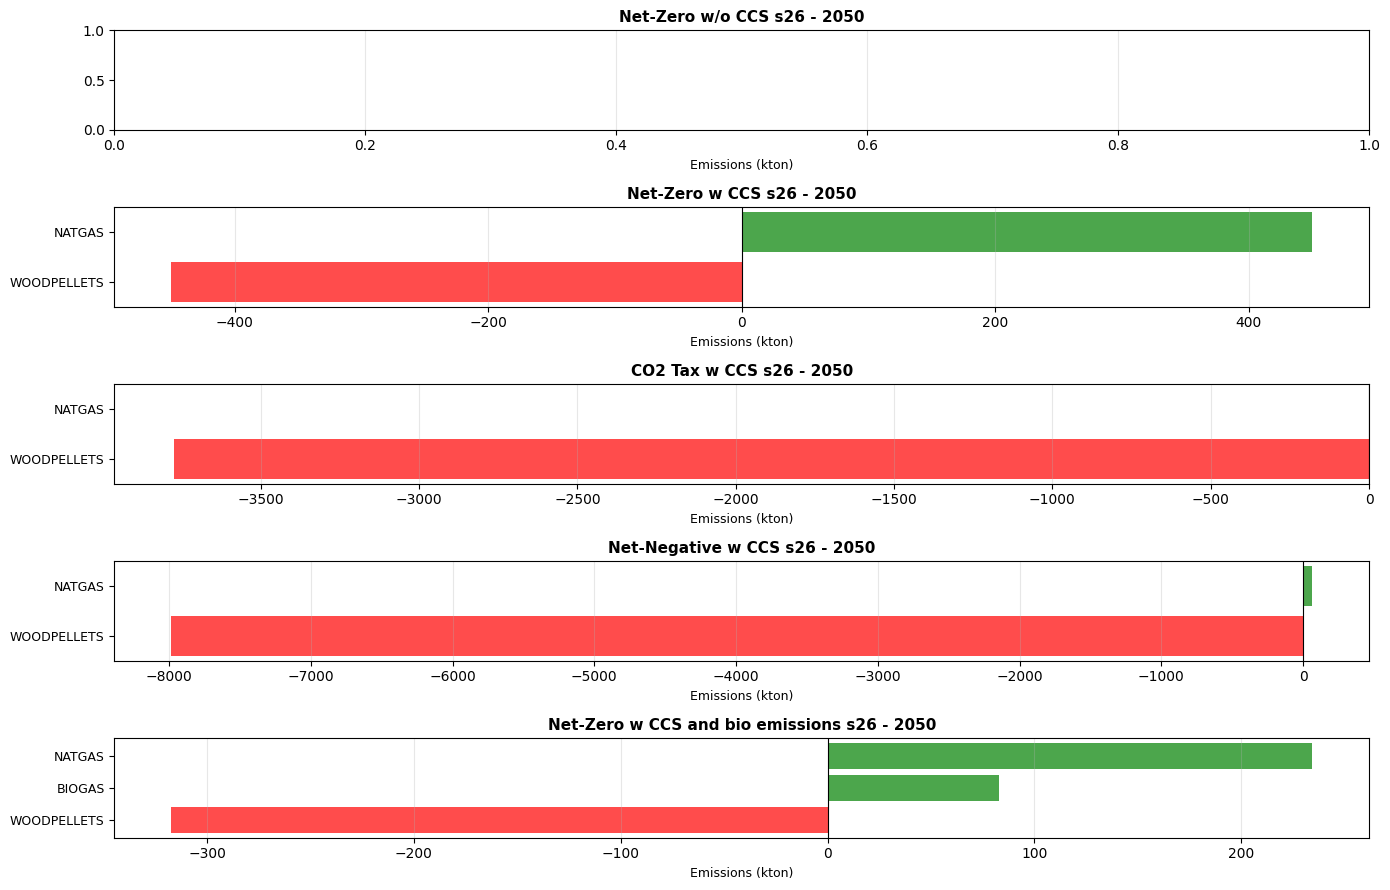

In [36]:
scenarios = [
    "Net-Zero w/o CCS s26",
    "Net-Zero w CCS s26",
    "CO2 Tax w CCS s26",
    "Net-Negative w CCS s26",
    "Net-Zero w CCS and bio emissions s26",
]
years = [2050]
fig, axes = pf.plot_emissions_grid_by_year_and_scenario(
    EMI_YCRAG, years=years, scenarios=scenarios
)

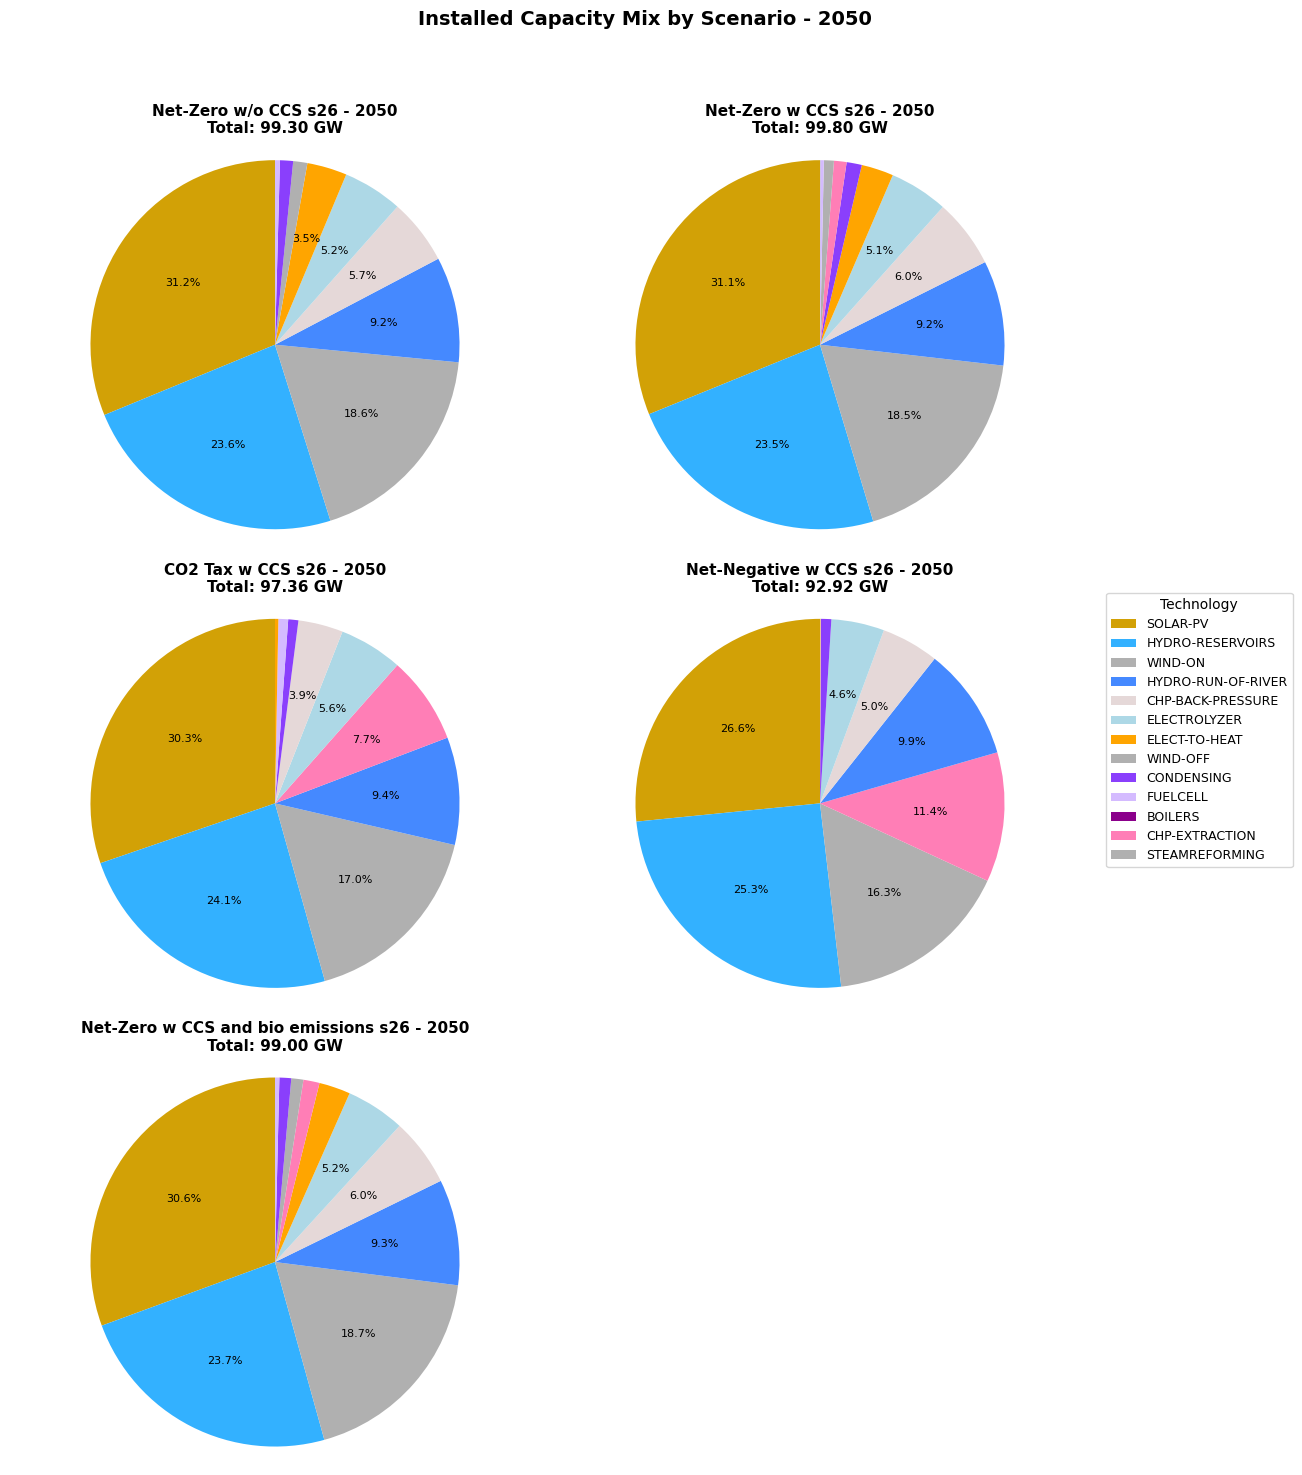

In [37]:
scenarios = [
    "Net-Zero w/o CCS s26",
    "Net-Zero w CCS s26",
    "CO2 Tax w CCS s26",
    "Net-Negative w CCS s26",
    "Net-Zero w CCS and bio emissions s26",
]

fig, ax = pf.plot_capacity_pie_by_scenario(
    G_CAP_YCRAF,
    year=2050,
    scenarios=scenarios,
    min_capacity=0.0,
)

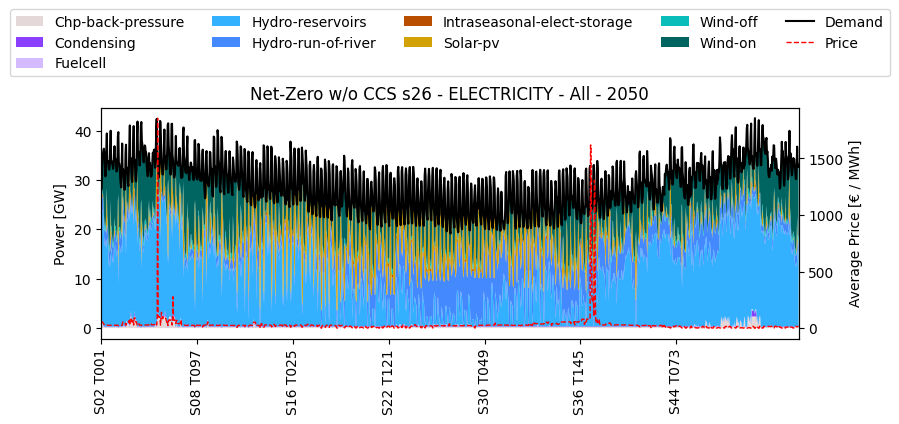

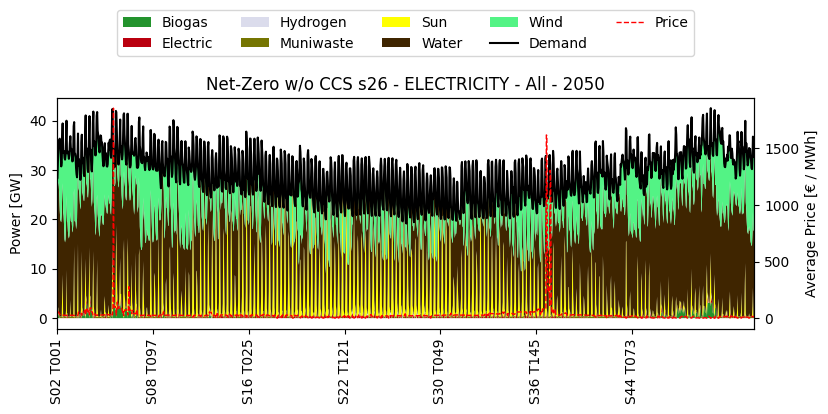

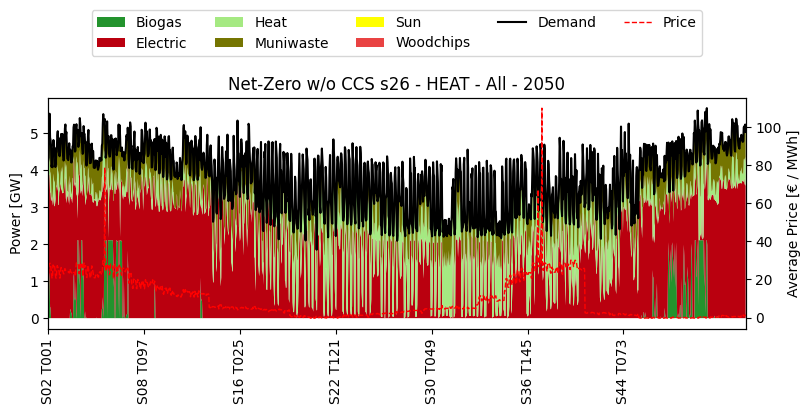

In [38]:
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS s26', year=2050, commodity='Heat', columns='Fuel')

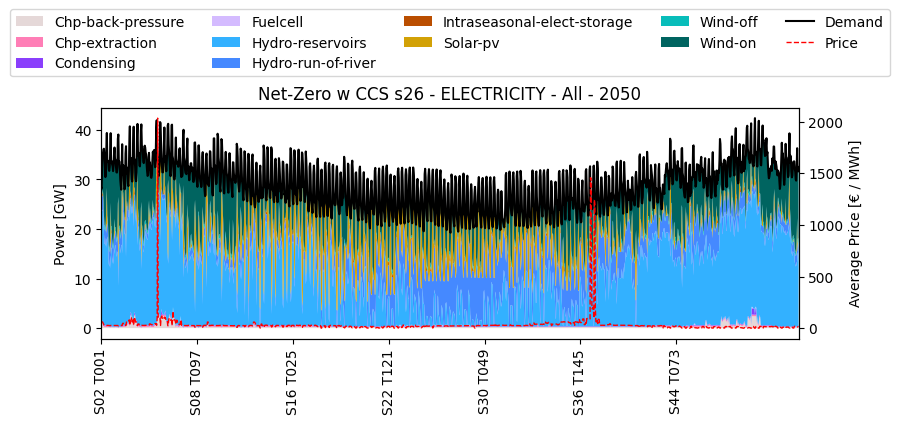

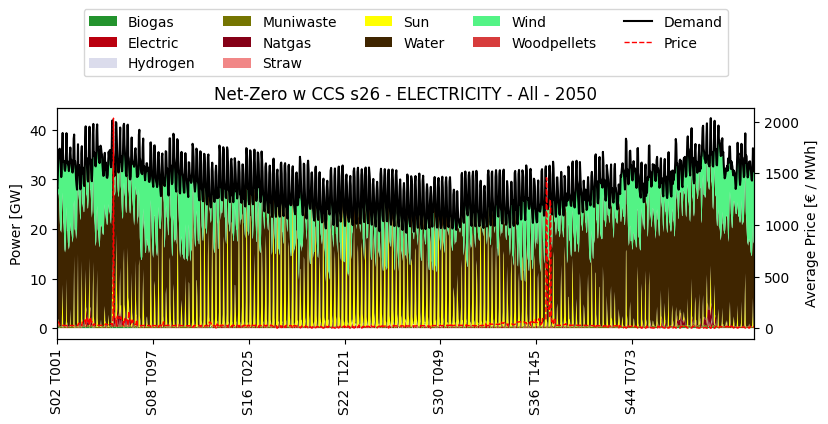

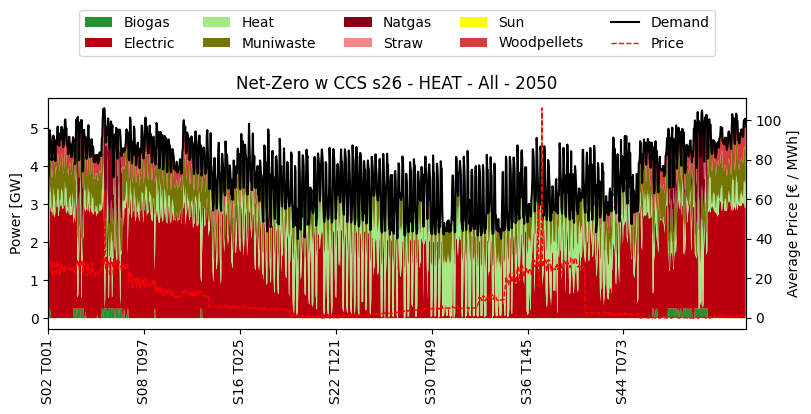

In [39]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS s26', year=2050, commodity='Heat', columns='Fuel')

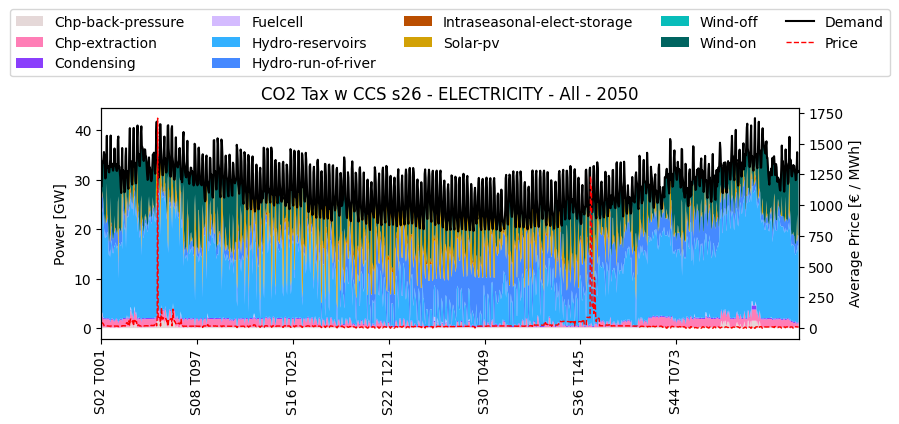

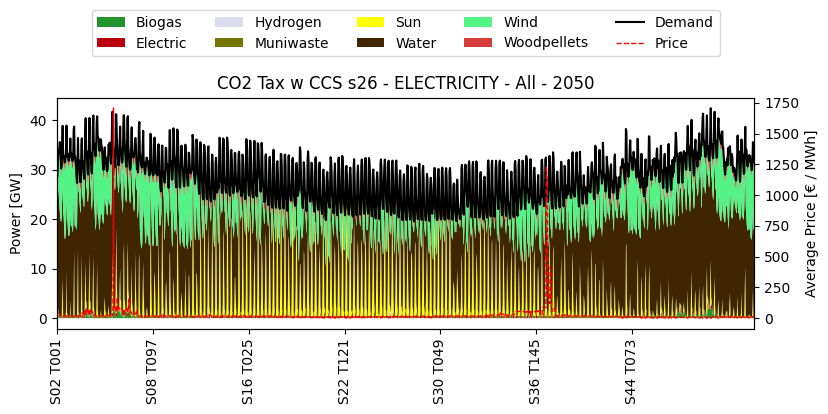

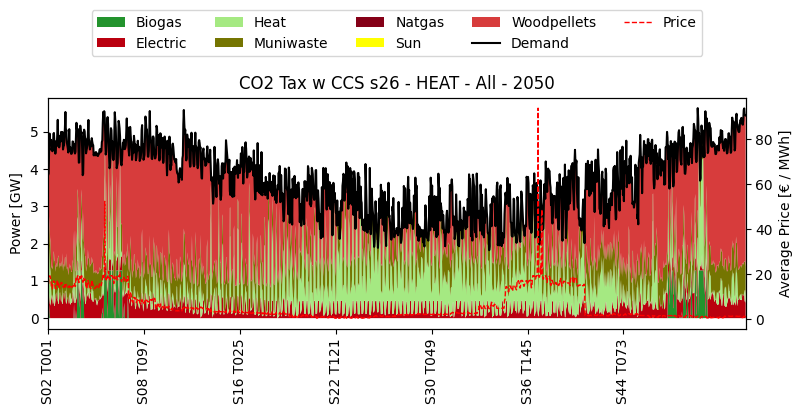

In [40]:
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS s26', year=2050, commodity='Heat', columns='Fuel')

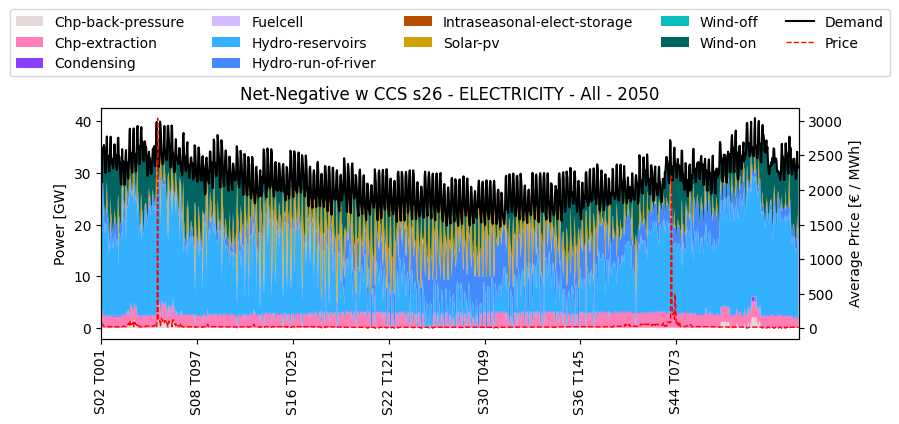

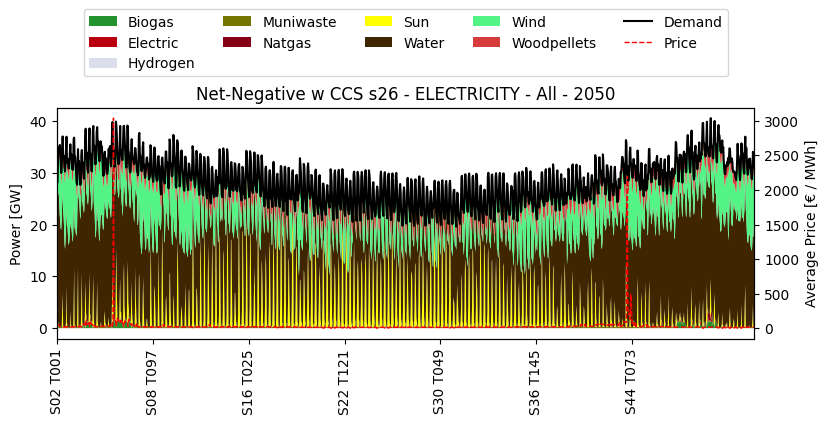

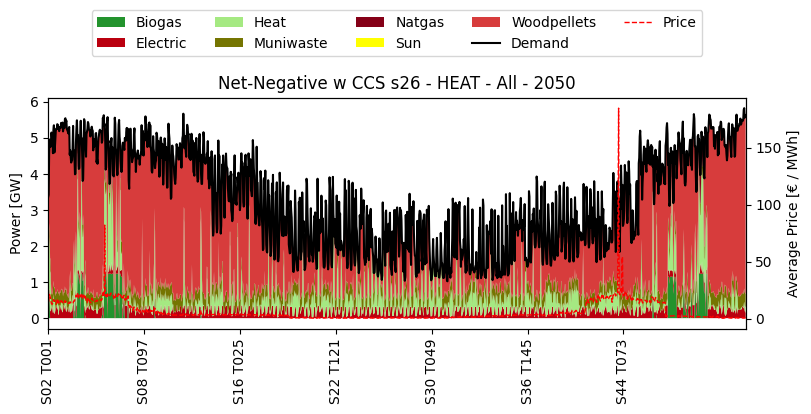

In [41]:
fig, ax = res.plot_profile(scenario='Net-Negative w CCS s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS s26', year=2050, commodity='Heat', columns='Fuel')

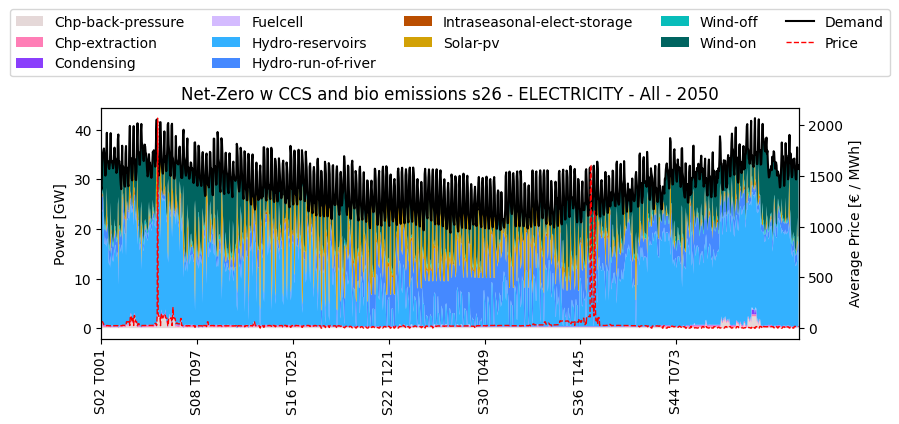

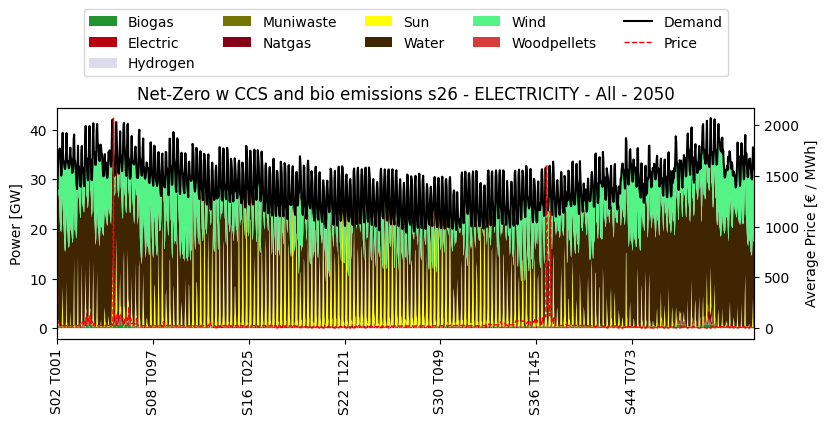

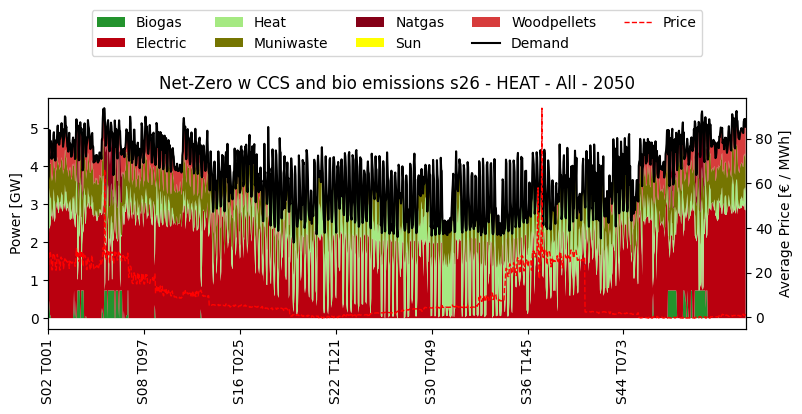

In [42]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS and bio emissions s26', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS and bio emissions s26', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS and bio emissions s26', year=2050, commodity='Heat', columns='Fuel')

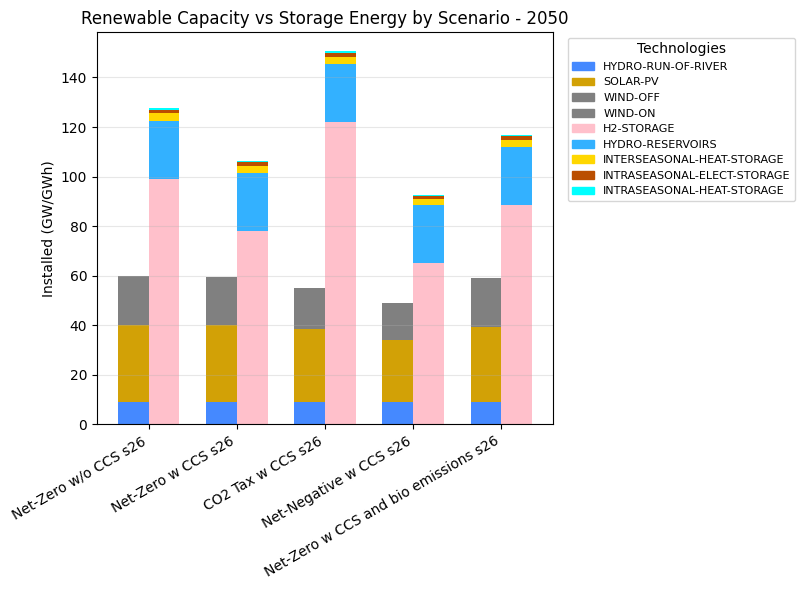

In [43]:
fig, ax = pf.plot_renewables_vs_storage_by_tech(G_CAP_YCRAF, year=2050, scenarios=["Net-Zero w/o CCS s26","Net-Zero w CCS s26","CO2 Tax w CCS s26","Net-Negative w CCS s26","Net-Zero w CCS and bio emissions s26"], min_capacity=0.0)

In [56]:
from typing import Tuple
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from pybalmorel.utils import symbol_to_df

def plot_annual_bio_profile(
    MainResults,
    scenario: str,
    year: int,
    commodity: str = "ELECTRICITY"
) -> Tuple[Figure, Axes]:
    """
    Plots an annual generation profile (Jan - Dec) specifically for bio-technologies,
    grouped into 'CHP-EXTRACTION' and 'Others'.
    """
    # 1. Access the database for the chosen scenario
    db = MainResults.db[scenario]
    year_str = str(year)
    commodity = commodity.upper()

    # 2. Extract the production data
    fProd = symbol_to_df(
        db,
        "PRO_YCRAGFST",
        cols=["Y", "C", "RRR", "AAA", "G", "Fuel", "SSS", "TTT", "COMMODITY", "Technology", "UNITS", "Val"],
    )

    # 3. Filter by Year and Commodity
    df = fProd[(fProd["Y"] == year_str) & (fProd["COMMODITY"] == commodity)].copy()

    # 4. Filter strictly for Bio-Fuels
    bio_fuels = ['STRAW', 'WOOD', 'WOODCHIPS', 'RECYCLEDWOOD', 'WOODPELLETS', 'WOODWASTE', 'BIOOIL', 'BIOGAS']
    df = df[df['Fuel'].str.upper().isin(bio_fuels)]

    if df.empty:
        print(f"No bio-technology generation found for {scenario} in {year}.")
        return plt.subplots()

    # Clean up whitespace from GAMS outputs
    df['SSS'] = df['SSS'].astype(str).str.strip()
    df['TTT'] = df['TTT'].astype(str).str.strip()
    df['Technology'] = df['Technology'].astype(str).str.strip()

    # -------------------------------------------------------------------------
    # 4.5 Group into two distinct categories
    # If the technology is CHP-EXTRACTION, keep it. Otherwise, rename to 'Others'.
    df['Technology'] = np.where(
        df['Technology'].str.upper() == 'CHP-EXTRACTION',
        'Biomass with CCS',
        'Biomass w/o CCS'
    )
    # -------------------------------------------------------------------------

    # 5. Pivot to get Technologies as columns and Time as rows
    # Because of step 4.5, this will now automatically sum all 'Others' together
    pivot_df = df.pivot_table(
        values="Val", 
        index=["SSS", "TTT"], 
        columns="Technology", 
        aggfunc="sum"
    ).fillna(0)

    # Ensure chronological sorting of standard Balmorel time steps
    pivot_df = pivot_df.sort_index()

    # 6. Transform SSS/TTT multi-index to a Jan-Dec DatetimeIndex
    timeslices = len(pivot_df)
    date_index = pd.date_range(
        start=f"{year}-01-01 00:00:00", 
        end=f"{year}-12-31 23:59:00", 
        periods=timeslices
    )
    pivot_df.index = date_index

    # Sort columns by total generation (largest at the bottom for cleaner stacking)
    pivot_df = pivot_df[pivot_df.sum().sort_values(ascending=False).index]

    # 7. Plotting
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Assign specific colors to the two categories
    colors = []
    for col in pivot_df.columns:
        if col == "Biomass with CCS":
            colors.append("#98DB98")  # Distinct light green
        else:
            colors.append("#4A90E2")  # Distinct solid blue

    # The clean stackplot method
    ax.stackplot(
        pivot_df.index, 
        pivot_df.T, 
        labels=pivot_df.columns, 
        colors=colors,
        alpha=0.9,
        step='mid'
    )

    # 8. Format X-Axis to strictly show Months
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    # Styling
    ax.set_title(f"Bio-Technology Generation Profile - {scenario} ({year})", fontsize=14, fontweight="bold")
    ax.set_ylabel("Generation (MWh)")
    ax.set_xlabel("Month")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xlim(pivot_df.index.min(), pivot_df.index.max())

    # Place legend outside the plot
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    plt.tight_layout()

    return fig, ax

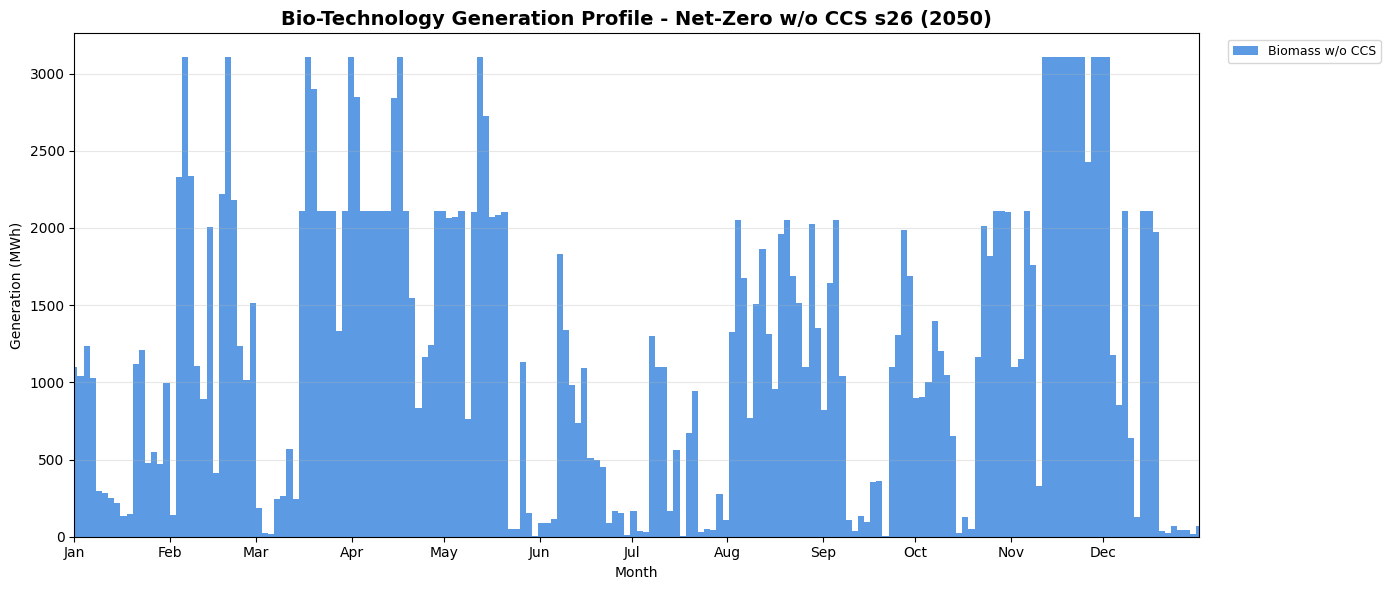

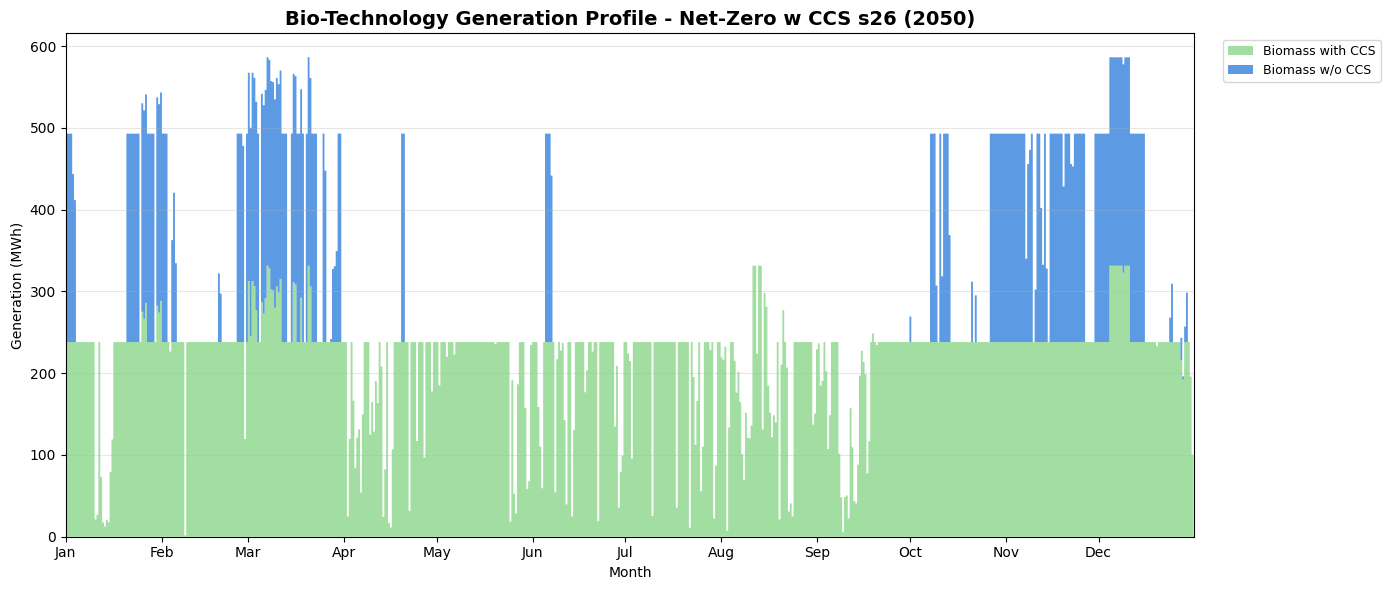

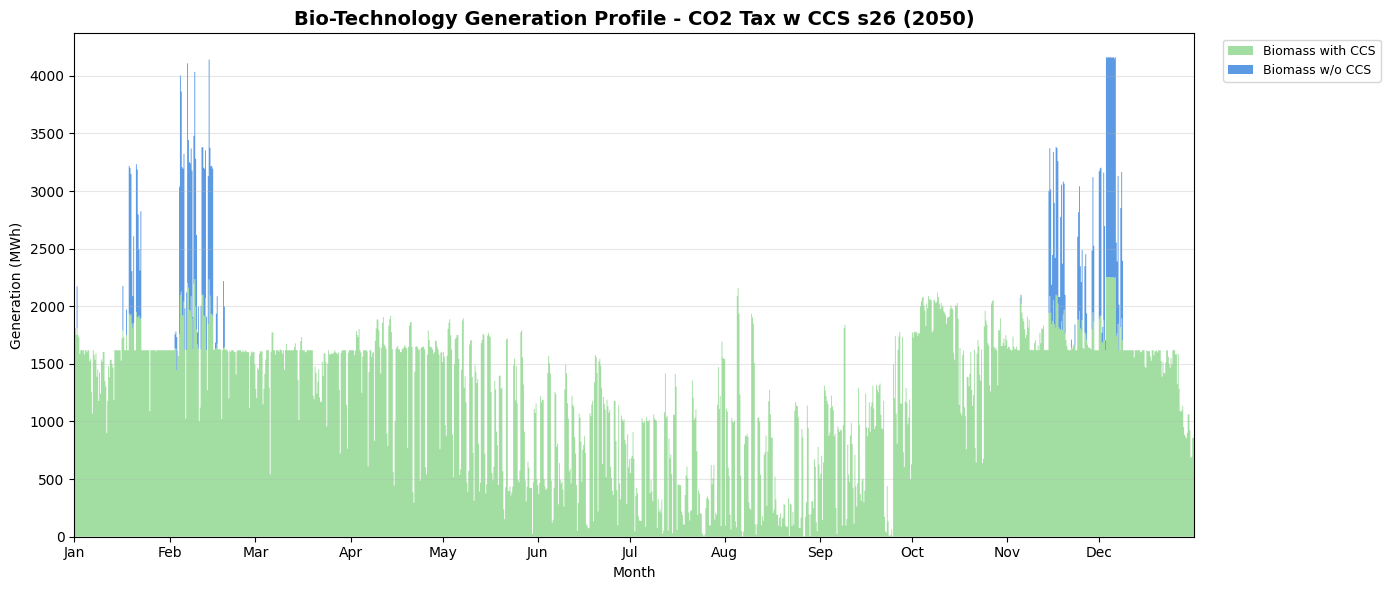

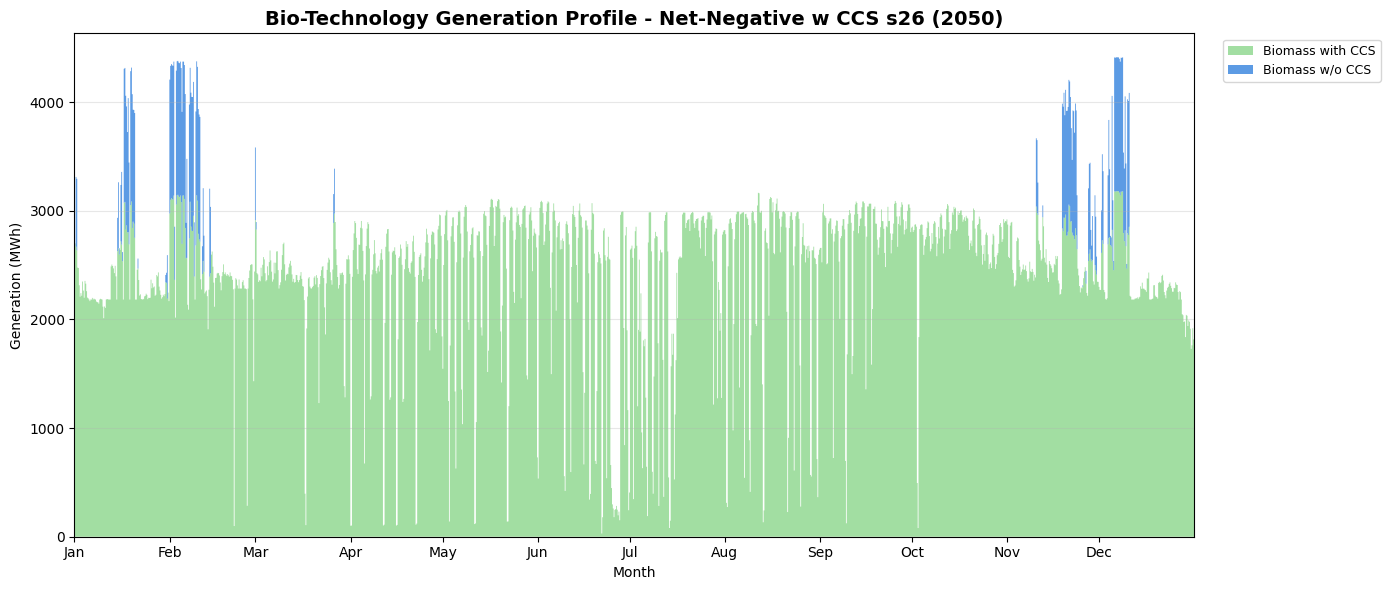

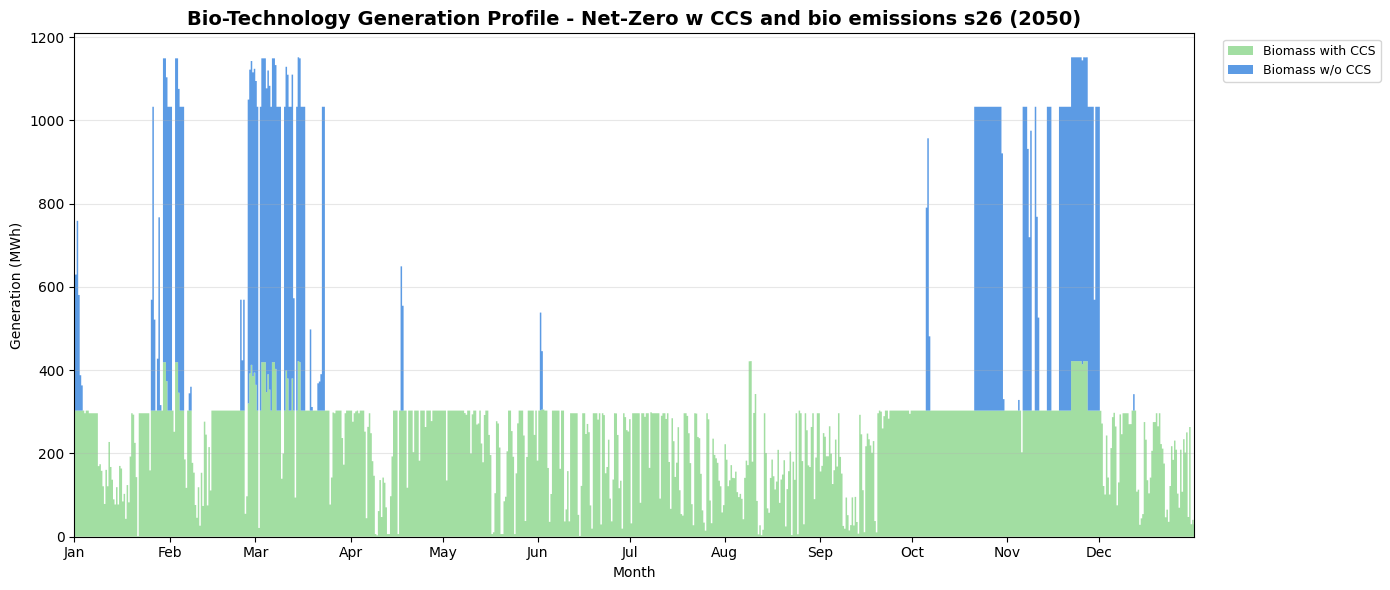

In [57]:
# Execute the custom bio-profile plot
fig1, ax1 = plot_annual_bio_profile(MainResults=res, scenario='Net-Zero w/o CCS s26', year=2050, commodity='Electricity')
fig2, ax2 = plot_annual_bio_profile(MainResults=res, scenario='Net-Zero w CCS s26', year=2050, commodity='Electricity')
fig3, ax3 = plot_annual_bio_profile(MainResults=res, scenario='CO2 Tax w CCS s26', year=2050, commodity='Electricity')
fig4, ax4 = plot_annual_bio_profile(MainResults=res, scenario='Net-Negative w CCS s26', year=2050, commodity='Electricity')
fig5, ax5 = plot_annual_bio_profile(MainResults=res, scenario='Net-Zero w CCS and bio emissions s26', year=2050, commodity='Electricity')
